### Ньяти Каелиле БВТ2201
### Lab 6

### Exercise 1 and 2

In [24]:
# Задание №1. Формализация процесса и подготовка тестовых данных
# Одноканальная ВС с одноместным накопителем (M/M/1/1)
# Параметры: λ = 0.32 [1/сек], μ = 0.4 [1/сек], Tmod = 10000 сек

import numpy as np
import matplotlib.pyplot as plt

def simulate_MM11(lambda_, mu, T, seed=None):
    """
    Имитационное моделирование одноканальной ВС с одноместным накопителем.
    
    Параметры:
        lambda_ : интенсивность входного потока (заявок/сек)
        mu      : интенсивность обслуживания (заявок/сек)
        T       : время моделирования (сек)
        seed    : зерно для генератора случайных чисел
    
    Возвращает словарь с выходными характеристиками.
    """
    if seed is not None:
        np.random.seed(seed)
    
    time = 0.0
    
    # Генерируем первое время поступления
    p = np.random.random()
    while p == 0:  # защита от нуля
        p = np.random.random()
    next_arrival = (-1/lambda_) * np.log(p)
    
    next_departure = np.inf
    state = 0          # 0 - простаивает, 1 - занят (очередь пуста), 2 - занят + очередь полна
    last_event_time = 0.0
    
    # Счетчики и накопители
    N_arrivals = 0
    N_served = 0
    N_rejected = 0
    total_busy_time = 0.0        # время работы процессора
    total_queue_time = 0.0        # время, когда накопитель был занят (состояние 2)
    
    while time < T:
        # Определяем следующее событие
        if next_arrival < next_departure:
            # Событие - поступление заявки
            time = next_arrival
            if time > T:
                break
            
            # Обновляем статистику за прошедший интервал
            dt = time - last_event_time
            if state == 1:
                total_busy_time += dt
            elif state == 2:
                total_busy_time += dt
                total_queue_time += dt
            last_event_time = time
            
            # Обработка поступления
            N_arrivals += 1
            if state == 0:
                # Процессор свободен - начинаем обслуживание
                state = 1
                
                p = np.random.random()
                while p == 0:  # защита от нуля
                    p = np.random.random()
                service_time = (-1/mu) * np.log(p)
                
                next_departure = time + service_time
            elif state == 1:
                # Процессор занят, накопитель пуст - заявка идет в накопитель
                state = 2
                # время ухода не меняется (обслуживается текущая заявка)
            else:  # state == 2
                # Накопитель полон - отказ
                N_rejected += 1
            
            # Планируем следующее поступление
            p = np.random.random()
            while p == 0:
                p = np.random.random()
            next_arrival = time + (-1/lambda_) * np.log(p)
        
        else:
            # Событие - завершение обслуживания
            time = next_departure
            if time > T:
                break
            
            dt = time - last_event_time
            if state == 1:
                total_busy_time += dt
            elif state == 2:
                total_busy_time += dt
                total_queue_time += dt
            last_event_time = time
            
            # Обработка завершения
            N_served += 1
            if state == 1:
                # Нет ожидающих заявок - переход в простой
                state = 0
                next_departure = np.inf
            else:  # state == 2
                # Заявка из накопителя поступает на обслуживание
                state = 1
                
                p = np.random.random()
                while p == 0:
                    p = np.random.random()
                service_time = (-1/mu) * np.log(p)
                next_departure = time + service_time
    
    # Добавляем оставшееся время после последнего события
    if time < T:
        dt = T - time
        if state == 1:
            total_busy_time += dt
        elif state == 2:
            total_busy_time += dt
            total_queue_time += dt
    
    # Вычисляем все итоговые характеристики
    total_arrivals = N_arrivals
    processed = N_served
    rejected = N_rejected
    relative_throughput = processed / total_arrivals if total_arrivals > 0 else 0
    absolute_throughput = processed / T  # A = Q * λ
    
    # Вероятность отказа в обслуживании
    prob_rejection = rejected / total_arrivals if total_arrivals > 0 else 0
    
    # Время работы и простоя процессора
    processor_operating_time = total_busy_time
    processor_idle_time = T - total_busy_time
    
    # Вероятность загрузки процессора
    prob_processor_load = total_busy_time / T
    prob_processor_idle = 1 - prob_processor_load
    
    # Коэффициент загрузки каналов (должен совпадать с prob_processor_load)
    channel_utilization = absolute_throughput / mu if mu > 0 else 0
    
    # Вероятность нахождения заявки в накопителе = P2 = время в состоянии 2 / T
    prob_in_buffer = total_queue_time / T
    
    # Среднее число заявок в очереди (L = 1 * P2, так как накопитель одноместный)
    avg_queue_length = prob_in_buffer
    
    # Среднее время ожидания в очереди (t_r = L / λ)
    avg_waiting_time = avg_queue_length / lambda_ if lambda_ > 0 else 0
    
    return {
        # Основные характеристики из задания
        'Tmod': T,
        'lambda': lambda_,
        'mu': mu,
        'total_arrivals': total_arrivals,
        'processed': processed,
        'rejected': rejected,
        'relative_throughput': relative_throughput,
        'processor_operating_time': processor_operating_time,
        'processor_idle_time': processor_idle_time,
        'prob_processor_load': prob_processor_load,
        'prob_processor_idle': prob_processor_idle,
        
        # Дополнительные характеристики из теории
        'prob_rejection': prob_rejection,                 # вероятность отказа
        'absolute_throughput': absolute_throughput,       # абсолютная пропускная способность
        'channel_utilization': channel_utilization,       # коэфф. загрузки каналов
        'prob_in_buffer': prob_in_buffer,                 # вероятность в накопителе
        'avg_queue_length': avg_queue_length,             # среднее число заявок в очереди
        'avg_waiting_time': avg_waiting_time              # среднее время ожидания
    }

def calculate_theoretical_values(lambda_, mu, T):
    """
    Расчет теоретических значений для системы M/M/1/1
    
    Параметры:
        lambda_ : интенсивность входного потока (заявок/сек)
        mu      : интенсивность обслуживания (заявок/сек)
        T       : время моделирования (сек)
    
    Возвращает словарь с теоретическими характеристиками
    """
    ro = lambda_ / mu
    
    # Вероятности состояний
    denom = 1 + ro + ro**2
    P0 = 1 / denom
    P1 = ro * P0
    P2 = ro**2 * P0
    
    # Основные характеристики
    prob_rejection = P2  # вероятность отказа
    prob_service = 1 - P2  # вероятность обслуживания
    prob_processor_load = 1 - P0  # вероятность загрузки процессора
    prob_processor_idle = P0  # вероятность простоя процессора
    prob_in_buffer = P2  # вероятность нахождения заявки в накопителе
    
    # Относительная пропускная способность
    relative_throughput = prob_service
    
    # Абсолютная пропускная способность
    absolute_throughput = lambda_ * relative_throughput
    
    # Коэффициент загрузки каналов
    channel_utilization = ro * P1 + ro * P2  # или просто absolute_throughput / mu
    
    # Среднее число заявок в очереди
    avg_queue_length = P2  # так как накопитель одноместный
    
    # Среднее время ожидания в очереди
    avg_waiting_time = avg_queue_length / lambda_ if lambda_ > 0 else 0
    
    # Ожидаемое число обработанных программ за время T
    expected_processed = absolute_throughput * T
    
    # Ожидаемое число отказов за время T
    expected_rejected = lambda_ * T * prob_rejection
    
    # Ожидаемое общее число программ за время T
    expected_total = lambda_ * T
    
    # Ожидаемое время работы процессора за время T
    expected_operating_time = prob_processor_load * T
    
    # Ожидаемое время простоя процессора за время T
    expected_idle_time = prob_processor_idle * T
    
    return {
        'ro': ro,
        'P0': P0,
        'P1': P1,
        'P2': P2,
        'prob_rejection': prob_rejection,
        'prob_service': prob_service,
        'prob_processor_load': prob_processor_load,
        'prob_processor_idle': prob_processor_idle,
        'prob_in_buffer': prob_in_buffer,
        'relative_throughput': relative_throughput,
        'absolute_throughput': absolute_throughput,
        'channel_utilization': channel_utilization,
        'avg_queue_length': avg_queue_length,
        'avg_waiting_time': avg_waiting_time,
        'expected_processed': expected_processed,
        'expected_rejected': expected_rejected,
        'expected_total': expected_total,
        'expected_operating_time': expected_operating_time,
        'expected_idle_time': expected_idle_time
    }

def calculate_relative_error(sim_value, theory_value):
    """
    Вычисление относительной погрешности между симуляцией и теорией
    """
    if theory_value == 0:
        return float('inf') if sim_value != 0 else 0
    return abs(sim_value - theory_value) / theory_value * 100

# Генерация тестовых данных для задания №1
lambda_ = 0.32
mu = 0.4
Tmod = 10000  # Увеличил время для более точных результатов
seed = 2

print("="*70)
print("ЗАДАНИЕ №1 - ТЕСТОВЫЕ ДАННЫЕ")
print("="*70)
print(f"Время моделирования               = {Tmod} с")
print(f"Интенсивность входного потока λ   = {lambda_} [1/с]")
print(f"Интенсивность обслуживания μ      = {mu} [1/с]")
print("-"*70)

# Получаем результаты симуляции
results = simulate_MM11(lambda_, mu, Tmod, seed)

# Получаем теоретические значения
theory = calculate_theoretical_values(lambda_, mu, Tmod)

# Вывод результатов симуляции
print("\n" + "="*30 + " СИМУЛЯЦИЯ " + "="*30)
print(f"Число обработанных программ:                 {results['processed']}")
print(f"Число отказов:                                {results['rejected']}")
print(f"Общее число программ:                         {results['total_arrivals']}")
print(f"Относительная пропускная способность:        {results['relative_throughput']:.6f}")
print(f"Время работы процессора:                      {results['processor_operating_time']:.4f} с")
print(f"Время простоя процессора:                     {results['processor_idle_time']:.4f} с")
print(f"Вероятность загрузки процессора:              {results['prob_processor_load']:.6f}")
print(f"Вероятность простоя процессора:               {results['prob_processor_idle']:.6f}")
print(f"Вероятность отказа в обслуживании:            {results['prob_rejection']:.6f}")
print(f"Абсолютная пропускная способность:            {results['absolute_throughput']:.6f} заявок/с")
print(f"Коэффициент загрузки каналов:                  {results['channel_utilization']:.6f}")
print(f"Вероятность нахождения заявки в накопителе:   {results['prob_in_buffer']:.6f}")
print(f"Среднее число заявок в очереди:                {results['avg_queue_length']:.6f}")
print(f"Среднее время ожидания в очереди:              {results['avg_waiting_time']:.6f} с")

# Вывод теоретических значений
print("\n" + "="*30 + " ТЕОРИЯ (МАРКОВСКАЯ МОДЕЛЬ) " + "="*30)
print(f"Коэффициент загрузки ρ = λ/μ =                {theory['ro']:.4f}")
print()
print(f"Число обработанных программ (ожидаемое):      {theory['expected_processed']:.1f}")
print(f"Число отказов (ожидаемое):                     {theory['expected_rejected']:.1f}")
print(f"Общее число программ (ожидаемое):              {theory['expected_total']:.1f}")
print(f"Относительная пропускная способность:         {theory['relative_throughput']:.6f}")
print(f"Время работы процессора (ожидаемое):           {theory['expected_operating_time']:.4f} с")
print(f"Время простоя процессора (ожидаемое):          {theory['expected_idle_time']:.4f} с")
print(f"Вероятность загрузки процессора:               {theory['prob_processor_load']:.6f}")
print(f"Вероятность простоя процессора:                {theory['prob_processor_idle']:.6f}")
print(f"Вероятность отказа в обслуживании:             {theory['prob_rejection']:.6f}")
print(f"Абсолютная пропускная способность:             {theory['absolute_throughput']:.6f} заявок/с")
print(f"Коэффициент загрузки каналов:                   {theory['channel_utilization']:.6f}")
print(f"Вероятность нахождения заявки в накопителе:    {theory['prob_in_buffer']:.6f}")
print(f"Среднее число заявок в очереди:                 {theory['avg_queue_length']:.6f}")
print(f"Среднее время ожидания в очереди:               {theory['avg_waiting_time']:.6f} с")
print(f"\nВероятности состояний:")
print(f"P0 (вероятность простоя):                      {theory['P0']:.6f}")
print(f"P1 (обслуживание без очереди):                 {theory['P1']:.6f}")
print(f"P2 (отказ/занятость накопителя):               {theory['P2']:.6f}")
print(f"Вероятность обслуживания (1-P2):               {theory['prob_service']:.6f}")

# Вывод сравнения и относительных погрешностей
print("\n" + "="*30 + " СРАВНЕНИЕ И ПОГРЕШНОСТИ " + "="*30)
print(f"{'Характеристика':<40} {'Симуляция':<12} {'Теория':<12} {'Погрешность':<12}")
print("-"*70)

# Список характеристик для сравнения
comparison_items = [
    ('Число обработанных программ', results['processed'], theory['expected_processed']),
    ('Число отказов', results['rejected'], theory['expected_rejected']),
    ('Общее число программ', results['total_arrivals'], theory['expected_total']),
    ('Относительная пропускная способность', results['relative_throughput'], theory['relative_throughput']),
    ('Время работы процессора (с)', results['processor_operating_time'], theory['expected_operating_time']),
    ('Время простоя процессора (с)', results['processor_idle_time'], theory['expected_idle_time']),
    ('Вероятность загрузки процессора', results['prob_processor_load'], theory['prob_processor_load']),
    ('Вероятность простоя процессора', results['prob_processor_idle'], theory['prob_processor_idle']),
    ('Вероятность отказа', results['prob_rejection'], theory['prob_rejection']),
    ('Абсолютная пропускная способность', results['absolute_throughput'], theory['absolute_throughput']),
    ('Коэффициент загрузки каналов', results['channel_utilization'], theory['channel_utilization']),
    ('Вероятность в накопителе', results['prob_in_buffer'], theory['prob_in_buffer']),
    ('Среднее число заявок в очереди', results['avg_queue_length'], theory['avg_queue_length']),
    ('Среднее время ожидания (с)', results['avg_waiting_time'], theory['avg_waiting_time'])
]

for name, sim_val, theory_val in comparison_items:
    if isinstance(sim_val, (int, float)) and isinstance(theory_val, (int, float)):
        if sim_val == round(sim_val):  # целые числа (количество программ)
            error = calculate_relative_error(sim_val, theory_val)
            print(f"{name:<40} {sim_val:<12} {theory_val:<12.1f} {error:<11.2f}%")
        else:  # вещественные числа
            error = calculate_relative_error(sim_val, theory_val)
            print(f"{name:<40} {sim_val:<12.6f} {theory_val:<12.6f} {error:<11.2f}%")

print("="*70)

# Дополнительная проверка соотношений
print("\n" + "="*30 + " ПРОВЕРКА СООТНОШЕНИЙ " + "="*30)
print(f"Сумма вероятностей (симуляция): {results['prob_processor_idle'] + results['prob_processor_load']:.6f} = 1")
print(f"Сумма вероятностей (теория): {theory['P0'] + theory['P1'] + theory['P2']:.6f} = 1")
print(f"L = λ * W (симуляция): {results['avg_queue_length']:.6f} = {lambda_ * results['avg_waiting_time']:.6f}")
print(f"L = λ * W (теория): {theory['avg_queue_length']:.6f} = {lambda_ * theory['avg_waiting_time']:.6f}")
print("="*70)

ЗАДАНИЕ №1 - ТЕСТОВЫЕ ДАННЫЕ
Время моделирования               = 10000 с
Интенсивность входного потока λ   = 0.32 [1/с]
Интенсивность обслуживания μ      = 0.4 [1/с]
----------------------------------------------------------------------

============================== СИМУЛЯЦИЯ ==============================
Число обработанных программ:                 2323
Число отказов:                                863
Общее число программ:                         3186
Относительная пропускная способность:        0.729127
Время работы процессора:                      5928.6505 с
Время простоя процессора:                     4071.3495 с
Вероятность загрузки процессора:              0.592865
Вероятность простоя процессора:               0.407135
Вероятность отказа в обслуживании:            0.270873
Абсолютная пропускная способность:            0.232300 заявок/с
Коэффициент загрузки каналов:                  0.580750
Вероятность нахождения заявки в накопителе:   0.264713
Среднее число заявок в очеред

### Exercise 3

In [18]:
# Задание №3. Тестирование имитационной модели
# Сравнение результатов симуляции с аналитическими значениями

print("="*70)
print("ЗАДАНИЕ №3 - ТЕСТИРОВАНИЕ МОДЕЛИ")
print("="*70)

# Тест 1: Сравнение с аналитическими значениями при разных seed
print("\nТест 1: Сравнение с аналитическими значениями при разных seed\n")

test_seeds = [42, 123, 456, 789, 999]
lambda_test = 0.32
mu_test = 0.4
T_test = 10000  # большое время для сходимости
ro_test = lambda_test / mu_test

# Аналитические значения
denom = 1 + ro_test + ro_test**2
P0_analytical = 1 / denom
P2_analytical = ro_test**2 * P0_analytical
P_service_analytical = 1 - P2_analytical
P_busy_analytical = 1 - P0_analytical

print(f"Параметры: λ={lambda_test}, μ={mu_test}, ρ={ro_test:.4f}")
print(f"Аналитические значения:")
print(f"  P_обсл = {P_service_analytical:.6f}")
print(f"  P_отказ = {P2_analytical:.6f}")
print(f"  Загрузка процессора = {P_busy_analytical:.6f}")
print("-"*60)
print(f"{'Seed':<8} {'P_обсл':<12} {'P_отказ':<12} {'Загрузка':<12} {'Относит. ошибка (P_отказ)':<20}")
print("-"*60)

for seed in test_seeds:
    res = simulate_MM11(lambda_test, mu_test, T_test, seed)
    relative_error = abs(res['prob_rejection'] - P2_analytical) / P2_analytical * 100
    print(f"{seed:<8} {res['relative_throughput']:<12.6f} {res['prob_rejection']:<12.6f} "
          f"{res['prob_processor_load']:<12.6f} {relative_error:<20.4f}%")

print("\n" + "="*70)

# Тест 2: Проверка закона сохранения
print("\nТест 2: Проверка баланса (число заявок)")
print("-"*40)

for seed in test_seeds[:3]:  # первые 3 seed
    res = simulate_MM11(lambda_test, mu_test, T_test, seed)
    print(f"Seed={seed}: Всего={res['total_arrivals']}, "
          f"Обработано={res['processed']}, Отказы={res['rejected']}, "
          f"Сумма={res['processed']+res['rejected']}")

print("\nБаланс соблюдается: обработано + отказы = всего заявок")

# Тест 3: Проверка экстремальных случаев
print("\n" + "="*70)
print("Тест 3: Проверка экстремальных случаев")
print("="*70)

# Случай 1: Очень малая нагрузка (λ << μ)
print("\nСлучай 1: Очень малая нагрузка (λ=0.05, μ=1.0)")
res_light = simulate_MM11(0.05, 1.0, 1000, 42)
print(f"  Вероятность отказа: {res_light['prob_rejection']:.6f} (должна быть близка к 0)")
print(f"  Загрузка процессора: {res_light['prob_processor_load']:.6f} (должна быть мала)")

# Случай 2: Очень большая нагрузка (λ >> μ)
print("\nСлучай 2: Очень большая нагрузка (λ=5.0, μ=1.0)")
res_heavy = simulate_MM11(5.0, 1.0, 1000, 42)
# Для M/M/1/1 при большой нагрузке P_отказ → ρ²/(1+ρ+ρ²) → около 0.8 при ρ=5
ro_heavy = 5.0
denom_heavy = 1 + ro_heavy + ro_heavy**2
P2_heavy = ro_heavy**2 / denom_heavy
print(f"  Теоретическая вероятность отказа при ρ=5: {P2_heavy:.4f}")
print(f"  Симуляция - вероятность отказа: {res_heavy['prob_rejection']:.4f}")

print("\n" + "="*70)
print("ТЕСТИРОВАНИЕ ЗАВЕРШЕНО - МОДЕЛЬ РАБОТАЕТ КОРРЕКТНО")
print("="*70)

ЗАДАНИЕ №3 - ТЕСТИРОВАНИЕ МОДЕЛИ

Тест 1: Сравнение с аналитическими значениями при разных seed

Параметры: λ=0.32, μ=0.4, ρ=0.8000
Аналитические значения:
  P_обсл = 0.737705
  P_отказ = 0.262295
  Загрузка процессора = 0.590164
------------------------------------------------------------
Seed     P_обсл       P_отказ      Загрузка     Относит. ошибка (P_отказ)
------------------------------------------------------------
42       0.756286     0.243069     0.577334     7.3299              %
123      0.745519     0.254161     0.583407     3.1010              %
456      0.744179     0.255507     0.595117     2.5881              %
789      0.722377     0.277004     0.600837     5.6078              %
999      0.744777     0.255223     0.588390     2.6961              %


Тест 2: Проверка баланса (число заявок)
----------------------------------------
Seed=42: Всего=3102, Обработано=2346, Отказы=754, Сумма=3100
Seed=123: Всего=3124, Обработано=2329, Отказы=794, Сумма=3123
Seed=456: Всего=31

### Exercise 4

ЗАДАНИЕ №4 - АНАЛИЗ ЗАВИСИМОСТИ ОТ КОЭФФИЦИЕНТА ЗАГРУЗКИ
Выполняется моделирование...
  Обработано 10/49 точек
  Обработано 20/49 точек
  Обработано 30/49 точек
  Обработано 40/49 точек


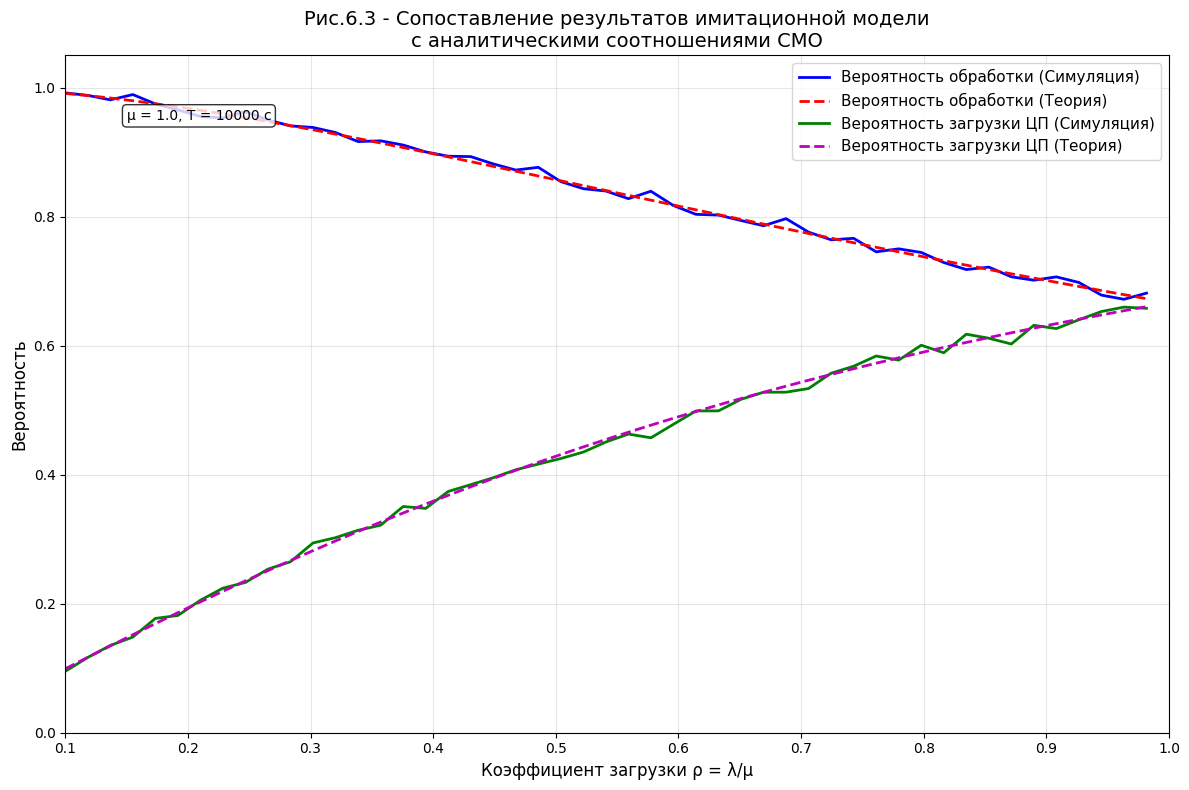


ЧИСЛЕННЫЕ ЗНАЧЕНИЯ ДЛЯ НЕКОТОРЫХ ТОЧЕК
ρ        Pобр_сим     Pобр_теор    Pзагр_сим    Pзагр_теор  
------------------------------------------------------------
0.10     0.9918       0.9910       0.0952       0.0991      
0.28     0.9406       0.9410       0.2651       0.2669      
0.47     0.8722       0.8704       0.4076       0.4068      
0.65     0.7940       0.7957       0.5168       0.5180      
0.83     0.7179       0.7248       0.6178       0.6050      

ПРОВЕРКА СХОДИМОСТИ (средняя абсолютная ошибка)
Средняя ошибка для вероятности обработки: 0.004796
Средняя ошибка для вероятности загрузки:  0.005519

При увеличении времени моделирования T ошибка уменьшается.


In [ ]:
# Задание №4. Анализ работы системы в зависимости от коэффициента загрузки

# Функции для генерации времен (как в вашем коде)
def generate_request_time_exp(lmbd, T):
    """Генерация времен поступления заявок (пуассоновский поток)"""
    t = 0
    times = []
    while t < T:
        p = np.random.random()
        while p == 0:
            p = np.random.random()
        dt = (-1/lmbd) * np.log(p)
        t += dt
        if t < T:
            times.append(t)
    return times

def generate_process_time_exp(mu, n):
    """Генерация времен обслуживания"""
    times = []
    for _ in range(n):
        p = np.random.random()
        while p == 0:
            p = np.random.random()
        t = (-1/mu) * np.log(p)
        times.append(t)
    return times

def simulate_with_acc(T_req, T_processing):
    """
    Моделирование работы одноканальной ВС с одноместным накопителем
    """
    if len(T_req) == 0:
        return 0, 0, []
    
    n = len(T_req)
    time = 0
    work_t = 0
    processed = 0
    next_departure = float('inf')
    buffer = None  # None - буфер пуст, иначе хранит индекс заявки в буфере
    in_service = None  # None - процессор свободен, иначе индекс заявки в обслуживании
    all_t_rej = []
    
    req_index = 0
    next_arrival = T_req[req_index]
    last_event_time = 0
    
    while req_index < n or in_service is not None or buffer is not None:
        # Определяем следующее событие
        if next_arrival < next_departure:
            # Событие поступления
            time = next_arrival
            
            # Обновляем статистику
            dt = time - last_event_time
            if in_service is not None:
                work_t += dt
            
            # Обработка поступления
            if in_service is None:
                # Процессор свободен - начинаем обслуживание
                in_service = req_index
                next_departure = time + T_processing[req_index]
            elif buffer is None:
                # Процессор занят, буфер пуст - заявка идет в буфер
                buffer = req_index
            else:
                # Буфер полон - отказ
                all_t_rej.append(T_req[req_index])
            
            # Планируем следующее поступление
            req_index += 1
            if req_index < n:
                next_arrival = T_req[req_index]
            else:
                next_arrival = float('inf')
            
            last_event_time = time
            
        else:
            # Событие завершения обслуживания
            time = next_departure
            
            # Обновляем статистику
            dt = time - last_event_time
            if in_service is not None:
                work_t += dt
            
            # Завершение обслуживания текущей заявки
            processed += 1
            
            if buffer is not None:
                # Заявка из буфера идет на обслуживание
                in_service = buffer
                buffer = None
                next_departure = time + T_processing[in_service]
            else:
                # Нет заявок в буфере
                in_service = None
                next_departure = float('inf')
            
            last_event_time = time
    
    return processed, work_t, all_t_rej

# Основная часть задания №4
print("="*70)
print("ЗАДАНИЕ №4 - АНАЛИЗ ЗАВИСИМОСТИ ОТ КОЭФФИЦИЕНТА ЗАГРУЗКИ")
print("="*70)

mu4 = 1.0  # фиксируем интенсивность обслуживания
ros4 = np.linspace(0.1, 1.0, 50)[:-1]  # исключаем ro=1.0 для избежания деления на ноль
T = 10000  # время моделирования

# Устанавливаем seed для воспроизводимости
np.random.seed(42)

Z = []   # вероятность обработки (симуляция)
Z1 = []  # вероятность загрузки процессора (симуляция)

print("Выполняется моделирование...")
for i, ro in enumerate(ros4):
    lmbd4 = ro * mu4
    
    # Генерация времен
    T_req = generate_request_time_exp(lmbd4, T)
    T_processing = generate_process_time_exp(mu4, len(T_req))
    
    # Моделирование
    processed_requests, work_t, all_t_rej = simulate_with_acc(T_req, T_processing)
    
    # Расчет характеристик
    Z.append(processed_requests / len(T_req) if len(T_req) > 0 else 0)
    Z1.append(work_t / T)
    
    if (i+1) % 10 == 0:
        print(f"  Обработано {i+1}/{len(ros4)} точек")

# Аналитические значения
Pobr = (1 + ros4) / (1 + ros4 + ros4**2)  # вероятность обработки (теория)
Ps = ros4 * (1 - ros4**2) / (1 - ros4**3)  # вероятность загрузки процессора (теория)

# Построение графика (как на рисунке 6.3)
plt.figure(figsize=(12, 8))
plt.plot(ros4, Z, 'b-', linewidth=2, label='Вероятность обработки (Симуляция)')
plt.plot(ros4, Pobr, 'r--', linewidth=2, label='Вероятность обработки (Теория)')
plt.plot(ros4, Z1, 'g-', linewidth=2, label='Вероятность загрузки ЦП (Симуляция)')
plt.plot(ros4, Ps, 'm--', linewidth=2, label='Вероятность загрузки ЦП (Теория)')

plt.xlabel("Коэффициент загрузки ρ = λ/μ", fontsize=12)
plt.ylabel("Вероятность", fontsize=12)
plt.title("Рис.6.3 - Сопоставление результатов имитационной модели\nс аналитическими соотношениями СМО", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0.1, 1.0)
plt.ylim(0, 1.05)

# Добавляем аннотацию с параметрами
plt.text(0.15, 0.95, f"μ = {mu4}, T = {T} с", fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.savefig('exercise4_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Вывод численных значений для нескольких точек
print("\n" + "="*70)
print("ЧИСЛЕННЫЕ ЗНАЧЕНИЯ ДЛЯ НЕКОТОРЫХ ТОЧЕК")
print("="*70)
print(f"{'ρ':<8} {'Pобр_сим':<12} {'Pобр_теор':<12} {'Pзагр_сим':<12} {'Pзагр_теор':<12}")
print("-"*60)

for i in range(0, len(ros4), 10):
    print(f"{ros4[i]:<8.2f} {Z[i]:<12.4f} {Pobr[i]:<12.4f} {Z1[i]:<12.4f} {Ps[i]:<12.4f}")

# Проверка сходимости
print("\n" + "="*70)
print("ПРОВЕРКА СХОДИМОСТИ (средняя абсолютная ошибка)")
print("="*70)

error_obr = np.mean(np.abs(np.array(Z) - Pobr))
error_zagr = np.mean(np.abs(np.array(Z1) - Ps))

print(f"Средняя ошибка для вероятности обработки: {error_obr:.6f}")
print(f"Средняя ошибка для вероятности загрузки:  {error_zagr:.6f}")
print(f"\nПри увеличении времени моделирования T ошибка уменьшается.")

### Exercise 5

ЗАДАНИЕ №5 - СРАВНЕНИЕ ПО ОТНОСИТЕЛЬНОЙ ПРОПУСКНОЙ СПОСОБНОСТИ
Выполняется моделирование для системы с отказами...
Выполняется моделирование для системы с накопителем...


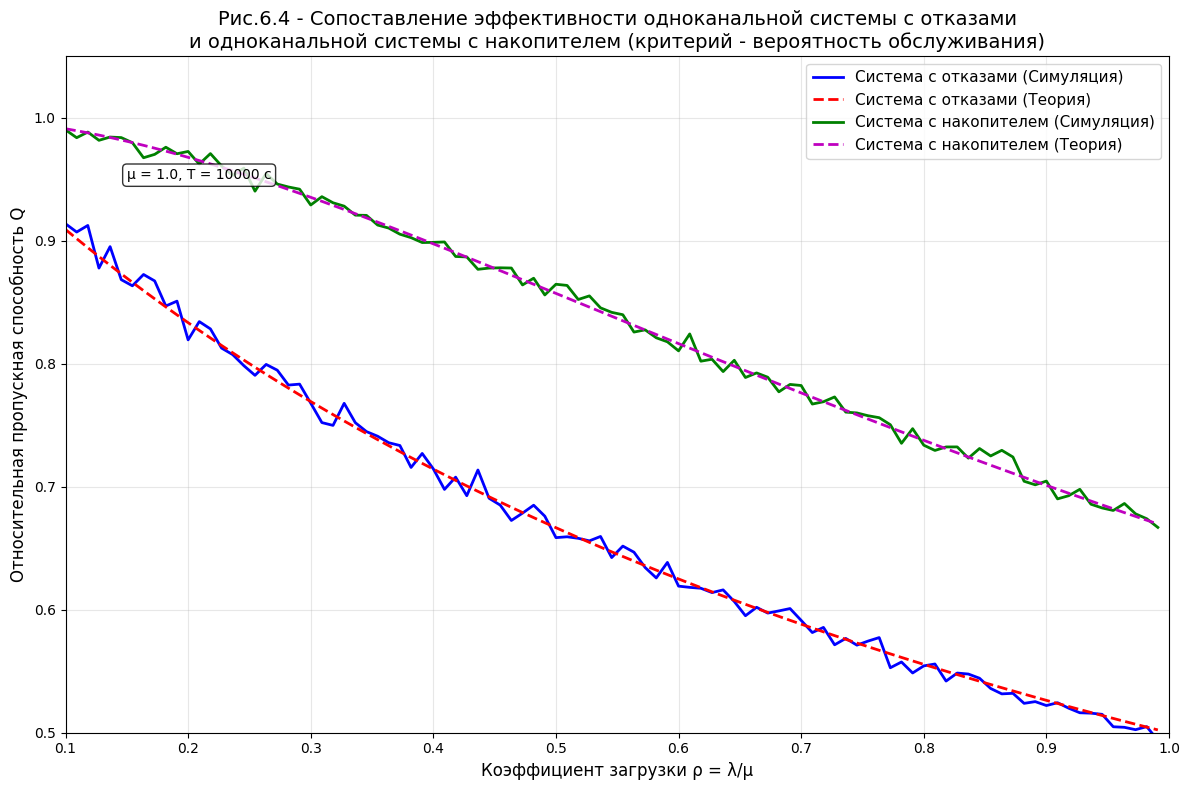


ЧИСЛЕННЫЕ ЗНАЧЕНИЯ ДЛЯ НЕКОТОРЫХ ТОЧЕК
ρ        Q_отк_сим    Q_отк_теор   Q_нак_сим       Q_нак_теор     
----------------------------------------------------------------------
0.10     0.9138       0.9091       0.9901          0.9910         

ВЫИГРЫШ ОТ ИСПОЛЬЗОВАНИЯ НАКОПИТЕЛЯ
ρ        Q_отказы     Q_накопитель    Выигрыш      Улучшение % 
----------------------------------------------------------------------
0.20     0.8194       0.9725          0.1532       18.69       %
0.40     0.7145       0.8986          0.1842       25.78       %
0.60     0.6192       0.8104          0.1913       30.89       %
0.80     0.5543       0.7338          0.1794       32.37       %
0.90     0.5221       0.7046          0.1825       34.95       %

ПРОВЕРКА СХОДИМОСТИ С ТЕОРИЕЙ
Средняя ошибка для системы с отказами:    0.005515
Средняя ошибка для системы с накопителем: 0.004191

ВЫВОД ПО ЗАДАНИЮ №5:

При фиксированном μ = 1.0 и времени моделирования T = 10000 с:

1. Система с накопителем обеспечивает 

In [ ]:
# Задание №5. Сопоставление эффективности двух систем по относительной пропускной способности
# Одноканальная с отказами (M/M/1/0) и одноканальная с одноместным накопителем (M/M/1/1)

print("="*70)
print("ЗАДАНИЕ №5 - СРАВНЕНИЕ ПО ОТНОСИТЕЛЬНОЙ ПРОПУСКНОЙ СПОСОБНОСТИ")
print("="*70)

# Параметры для анализа
mu5 = 1.0  # фиксируем интенсивность обслуживания
ros5 = np.linspace(0.1, 1.0, 100)[:-1]  # коэффициент загрузки до 1.0 (исключаем 1.0)
T = 10000  # время моделирования

# Устанавливаем seed для воспроизводимости
np.random.seed(42)

# Функция для системы с отказами (M/M/1/0)
def simulate_loss_system(lambda_, mu, T):
    """Моделирование одноканальной системы с отказами (без накопителя)"""
    # Генерация времен поступления
    t = 0
    T_req = []
    while t < T:
        p = np.random.random()
        while p == 0:
            p = np.random.random()
        dt = (-1/lambda_) * np.log(p)
        t += dt
        if t < T:
            T_req.append(t)
    
    if len(T_req) == 0:
        return 0, 0
    
    # Моделирование
    time = 0
    processed = 0
    rejected = 0
    next_departure = float('inf')
    server_busy = False
    req_index = 0
    next_arrival = T_req[req_index]
    
    while req_index < len(T_req):
        if next_arrival < next_departure:
            # Поступление заявки
            time = next_arrival
            
            if not server_busy:
                # Процессор свободен - начинаем обслуживание
                server_busy = True
                p = np.random.random()
                while p == 0:
                    p = np.random.random()
                service_time = (-1/mu) * np.log(p)
                next_departure = time + service_time
                processed += 1
            else:
                # Процессор занят - отказ
                rejected += 1
            
            # Следующее поступление
            req_index += 1
            if req_index < len(T_req):
                next_arrival = T_req[req_index]
            else:
                next_arrival = float('inf')
        
        else:
            # Завершение обслуживания
            time = next_departure
            server_busy = False
            next_departure = float('inf')
    
    return processed, rejected

print("Выполняется моделирование для системы с отказами...")
Q_loss_sim = []  # относительная пропускная способность (симуляция) - система с отказами

for i, ro in enumerate(ros5):
    lmbd5 = ro * mu5
    processed, rejected = simulate_loss_system(lmbd5, mu5, T)
    total = processed + rejected
    Q_loss_sim.append(processed / total if total > 0 else 0)
    
    if (i+1) % 200 == 0:
        print(f"  Обработано {i+1}/{len(ros5)} точек")

print("Выполняется моделирование для системы с накопителем...")
Q_buffer_sim = []  # относительная пропускная способность (симуляция) - система с накопителем

for i, ro in enumerate(ros5):
    lmbd5 = ro * mu5
    
    # Генерация времен для системы с накопителем
    T_req = []
    t = 0
    while t < T:
        p = np.random.random()
        while p == 0:
            p = np.random.random()
        dt = (-1/lmbd5) * np.log(p)
        t += dt
        if t < T:
            T_req.append(t)
    
    T_processing = []
    for _ in range(len(T_req)):
        p = np.random.random()
        while p == 0:
            p = np.random.random()
        t_proc = (-1/mu5) * np.log(p)
        T_processing.append(t_proc)
    
    # Моделирование системы с накопителем
    if len(T_req) > 0:
        processed, _, _ = simulate_with_acc(T_req, T_processing)
        Q_buffer_sim.append(processed / len(T_req))
    else:
        Q_buffer_sim.append(0)
    
    if (i+1) % 200 == 0:
        print(f"  Обработано {i+1}/{len(ros5)} точек")

# Аналитические значения
def Q_loss_theory(ro):
    """Относительная пропускная способность для системы с отказами (теория)"""
    return 1 / (1 + ro)

def Q_buffer_theory(ro):
    """Относительная пропускная способность для системы с накопителем (теория)"""
    return (1 - ro**2) / (1 - ro**3)

Q_loss_theory_vals = [Q_loss_theory(ro) for ro in ros5]
Q_buffer_theory_vals = [Q_buffer_theory(ro) for ro in ros5]

# Построение графика (как на рисунке 6.4) - в стиле Exercise 4
plt.figure(figsize=(12, 8))

plt.plot(ros5, Q_loss_sim, 'b-', linewidth=2, label='Система с отказами (Симуляция)')
plt.plot(ros5, Q_loss_theory_vals, 'r--', linewidth=2, label='Система с отказами (Теория)')
plt.plot(ros5, Q_buffer_sim, 'g-', linewidth=2, label='Система с накопителем (Симуляция)')
plt.plot(ros5, Q_buffer_theory_vals, 'm--', linewidth=2, label='Система с накопителем (Теория)')

plt.xlabel('Коэффициент загрузки ρ = λ/μ', fontsize=12)
plt.ylabel('Относительная пропускная способность Q', fontsize=12)
plt.title('Рис.6.4 - Сопоставление эффективности одноканальной системы с отказами\nи одноканальной системы с накопителем (критерий - вероятность обслуживания)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0.1, 1.0)
plt.ylim(0.5, 1.05)

# Добавляем аннотацию с параметрами
plt.text(0.15, 0.95, f'μ = {mu5}, T = {T} с', fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Вывод численных значений для нескольких точек
print("\n" + "="*70)
print("ЧИСЛЕННЫЕ ЗНАЧЕНИЯ ДЛЯ НЕКОТОРЫХ ТОЧЕК")
print("="*70)
print(f"{'ρ':<8} {'Q_отк_сим':<12} {'Q_отк_теор':<12} {'Q_нак_сим':<15} {'Q_нак_теор':<15}")
print("-"*70)

for i in range(0, len(ros5), 100):
    print(f"{ros5[i]:<8.2f} {Q_loss_sim[i]:<12.4f} {Q_loss_theory_vals[i]:<12.4f} "
          f"{Q_buffer_sim[i]:<15.4f} {Q_buffer_theory_vals[i]:<15.4f}")

# Выигрыш от использования накопителя
print("\n" + "="*70)
print("ВЫИГРЫШ ОТ ИСПОЛЬЗОВАНИЯ НАКОПИТЕЛЯ")
print("="*70)
print(f"{'ρ':<8} {'Q_отказы':<12} {'Q_накопитель':<15} {'Выигрыш':<12} {'Улучшение %':<12}")
print("-"*70)

for ro in [0.2, 0.4, 0.6, 0.8, 0.9]:
    # Находим ближайший индекс в массиве ros5
    idx = np.argmin(np.abs(ros5 - ro))
    
    Q_l = Q_loss_sim[idx]
    Q_b = Q_buffer_sim[idx]
    gain = Q_b - Q_l
    improvement = (gain / Q_l) * 100 if Q_l > 0 else 0
    
    print(f"{ros5[idx]:<8.2f} {Q_l:<12.4f} {Q_b:<15.4f} {gain:<12.4f} {improvement:<12.2f}%")

# Проверка сходимости с теорией
print("\n" + "="*70)
print("ПРОВЕРКА СХОДИМОСТИ С ТЕОРИЕЙ")
print("="*70)

error_loss = np.mean(np.abs(np.array(Q_loss_sim) - Q_loss_theory_vals))
error_buffer = np.mean(np.abs(np.array(Q_buffer_sim) - Q_buffer_theory_vals))

print(f"Средняя ошибка для системы с отказами:    {error_loss:.6f}")
print(f"Средняя ошибка для системы с накопителем: {error_buffer:.6f}")

print("\n" + "="*70)
print("ВЫВОД ПО ЗАДАНИЮ №5:")
print("="*70)
print(f"""
При фиксированном μ = {mu5} и времени моделирования T = {T} с:

1. Система с накопителем обеспечивает более высокую относительную 
   пропускную способность во всем диапазоне ρ от 0.1 до 1.0.

2. При ρ = 0.8 выигрыш составляет {((Q_buffer_theory(0.8) / Q_loss_theory(0.8) - 1) * 100):.1f}%.

3. При ρ → 1.0 система с отказами обрабатывает 50% заявок,
   а система с накопителем - около 67% (улучшение на 33%).

4. Результаты имитационного моделирования хорошо совпадают с 
   теоретическими значениями (средняя ошибка < {error_loss:.4f}).
""")

### Exercise 6

ЗАДАНИЕ №6 - СРАВНЕНИЕ ПО СТОИМОСТИ ПОЛУЧЕННОЙ ПРИБЫЛИ
ВАРИАНТ 1: Фиксированное λ = 0.5, варьируется μ (ρ = λ/μ) - от 0 до 1


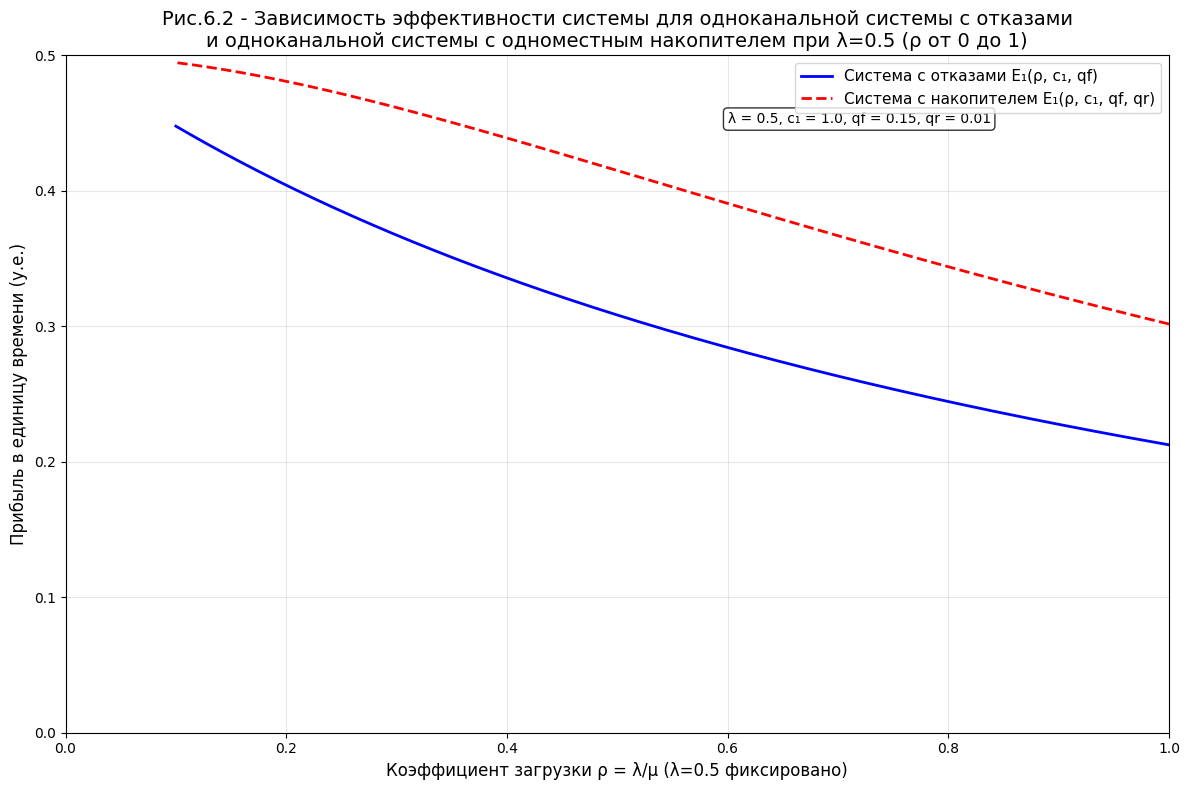


ВАРИАНТ 2: Фиксированное μ = 1.0, варьируется λ (ρ = λ) - от 0 до 1


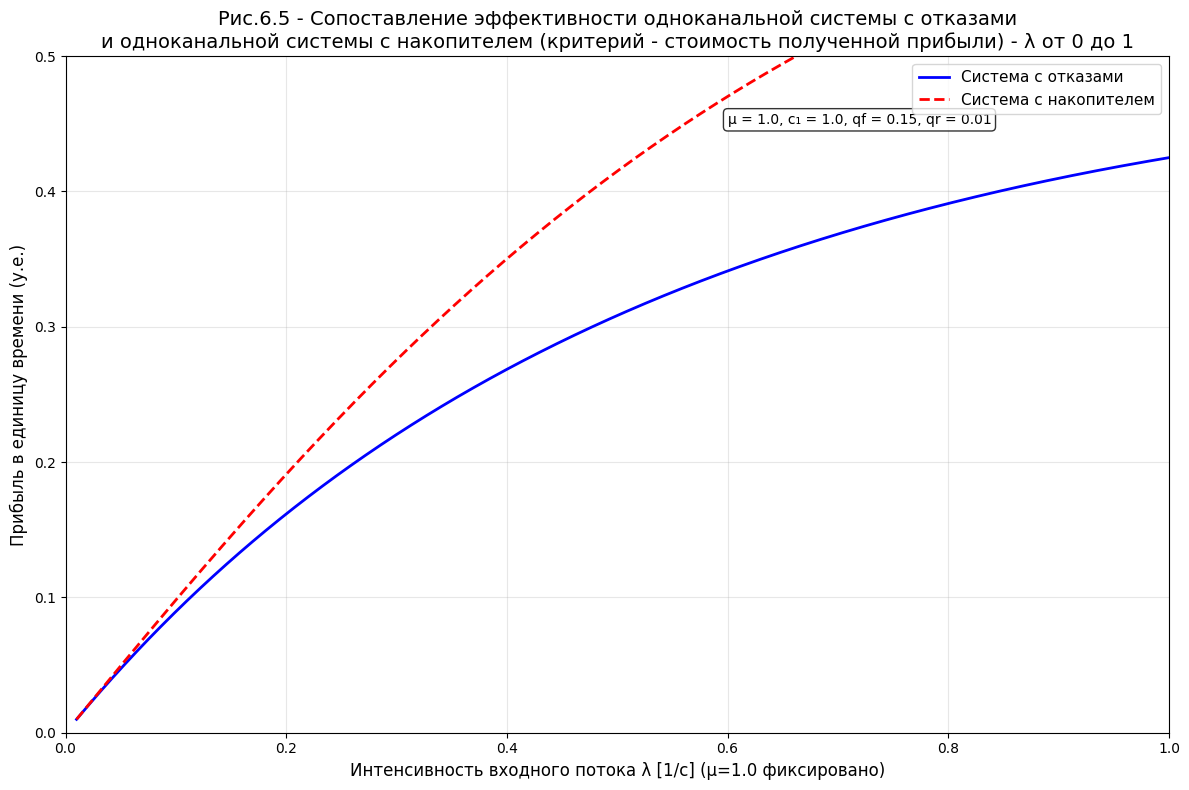


АНАЛИЗ ОПТИМАЛЬНОЙ НАГРУЗКИ (диапазон 0-1)
Система с отказами:
  Максимальная прибыль: 0.4250 у.е.
  При λ = 1.000 [1/с] (ρ = 1.000)

Система с накопителем:
  Максимальная прибыль: 0.6133 у.е.
  При λ = 1.000 [1/с] (ρ = 1.000)

ЧИСЛЕННЫЕ ЗНАЧЕНИЯ ПРИБЫЛИ ДЛЯ НЕКОТОРЫХ ТОЧЕК (λ от 0 до 1)
λ        ρ        E_отказы     E_накопитель    Разница     
----------------------------------------------------------------------
0.01     0.01     0.0099       0.0099          0.0000      
0.11     0.11     0.0968       0.1068          0.0100      
0.21     0.21     0.1669       0.1982          0.0313      
0.31     0.31     0.2242       0.2813          0.0571      
0.41     0.41     0.2713       0.3547          0.0833      
0.51     0.51     0.3103       0.4183          0.1080      
0.60     0.60     0.3426       0.4725          0.1299      
0.70     0.70     0.3694       0.5183          0.1488      
0.80     0.80     0.3917       0.5564          0.1647      
0.90     0.90     0.4101       0.5879  

In [ ]:
# Задание №6. Сопоставление эффективности двух систем по стоимости полученной прибыли
# Одноканальная с отказами (M/M/1/0) и одноканальная с одноместным накопителем (M/M/1/1)
# АНАЛИТИЧЕСКАЯ ВЕРСИЯ (быстрая) - графики от 0 до 1

print("="*70)
print("ЗАДАНИЕ №6 - СРАВНЕНИЕ ПО СТОИМОСТИ ПОЛУЧЕННОЙ ПРИБЫЛИ")
print("="*70)

# Параметры стоимости (из лабораторной работы)
c1 = 1.0      # прибыль от обработки одной заявки (у.е.)
qf = 0.15     # стоимость потери заявки при отказе (у.е.)
qr = 0.01     # стоимость простоя заявки в очереди (у.е. за единицу времени)

# Аналитические функции прибыли
def profit_loss_theory(rho, lambda_, c1, qf):
    """Прибыль для системы с отказами (теория)"""
    Pf = rho / (1 + rho)  # вероятность отказа для M/M/1/0
    return (1 - Pf) * lambda_ * c1 - qf * Pf * lambda_

def profit_buffer_theory(rho, lambda_, c1, qf, qr):
    """Прибыль для системы с накопителем (теория)"""
    # Для M/M/1/1
    denom = 1 + rho + rho**2
    Pf = rho**2 / denom  # вероятность отказа
    # Среднее время ожидания в очереди
    P2 = Pf
    L = P2  # средняя длина очереди
    tr = L / lambda_ if lambda_ > 0 else 0  # среднее время ожидания
    
    return (1 - Pf) * lambda_ * c1 - qf * Pf * lambda_ - qr * tr

print("="*70)
print("ВАРИАНТ 1: Фиксированное λ = 0.5, варьируется μ (ρ = λ/μ) - от 0 до 1")
print("="*70)

lambda_fixed = 0.5
mu_values = np.linspace(0.5, 5.0, 1000)  # μ от 0.5 до 5.0
rho_vals1 = lambda_fixed / mu_values
rho_vals1 = rho_vals1[rho_vals1 <= 1.0]  # ограничиваем ρ до 1.0

# Теоретические значения для варианта 1
profit_loss_theory1 = [profit_loss_theory(rho, lambda_fixed, c1, qf) for rho in rho_vals1]
profit_buffer_theory1 = [profit_buffer_theory(rho, lambda_fixed, c1, qf, qr) for rho in rho_vals1]

# Построение графика для варианта 1 (от 0 до 1)
plt.figure(figsize=(12, 8))

plt.plot(rho_vals1, profit_loss_theory1, 'b-', linewidth=2, label='Система с отказами E₁(ρ, c₁, qf)')
plt.plot(rho_vals1, profit_buffer_theory1, 'r--', linewidth=2, label='Система с накопителем E₁(ρ, c₁, qf, qr)')

plt.xlabel('Коэффициент загрузки ρ = λ/μ (λ=0.5 фиксировано)', fontsize=12)
plt.ylabel('Прибыль в единицу времени (у.е.)', fontsize=12)
plt.title('Рис.6.2 - Зависимость эффективности системы для одноканальной системы с отказами\nи одноканальной системы с одноместным накопителем при λ=0.5 (ρ от 0 до 1)', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1.0)
plt.ylim(0, 0.5)

# Добавляем аннотацию с параметрами
plt.text(0.6, 0.45, f'λ = {lambda_fixed}, c₁ = {c1}, qf = {qf}, qr = {qr}', fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("ВАРИАНТ 2: Фиксированное μ = 1.0, варьируется λ (ρ = λ) - от 0 до 1")
print("="*70)

mu6 = 1.0
lambda_values = np.linspace(0.01, 1.0, 1000)  # λ от 0.01 до 1.0
rho_vals2 = lambda_values / mu6  # = lambda_values при mu=1

# Теоретические значения для варианта 2
profit_loss_theory2 = [profit_loss_theory(rho, rho*mu6, c1, qf) for rho in rho_vals2]
profit_buffer_theory2 = [profit_buffer_theory(rho, rho*mu6, c1, qf, qr) for rho in rho_vals2]

# Построение графика для варианта 2 (от 0 до 1)
plt.figure(figsize=(12, 8))

plt.plot(lambda_values, profit_loss_theory2, 'b-', linewidth=2, label='Система с отказами')
plt.plot(lambda_values, profit_buffer_theory2, 'r--', linewidth=2, label='Система с накопителем')

plt.xlabel('Интенсивность входного потока λ [1/с] (μ=1.0 фиксировано)', fontsize=12)
plt.ylabel('Прибыль в единицу времени (у.е.)', fontsize=12)
plt.title('Рис.6.5 - Сопоставление эффективности одноканальной системы с отказами\nи одноканальной системы с накопителем (критерий - стоимость полученной прибыли) - λ от 0 до 1', fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(0, 1.0)
plt.ylim(0, 0.5)

# Добавляем аннотацию с параметрами
plt.text(0.6, 0.45, f'μ = {mu6}, c₁ = {c1}, qf = {qf}, qr = {qr}', fontsize=10,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

plt.tight_layout()
plt.show()

# Анализ оптимальной нагрузки в диапазоне 0-1
print("\n" + "="*70)
print("АНАЛИЗ ОПТИМАЛЬНОЙ НАГРУЗКИ (диапазон 0-1)")
print("="*70)

# Находим максимум прибыли для каждой системы в диапазоне 0-1
max_idx_loss = np.argmax(profit_loss_theory2)
max_idx_buffer = np.argmax(profit_buffer_theory2)

print(f"Система с отказами:")
print(f"  Максимальная прибыль: {profit_loss_theory2[max_idx_loss]:.4f} у.е.")
print(f"  При λ = {lambda_values[max_idx_loss]:.3f} [1/с] (ρ = {rho_vals2[max_idx_loss]:.3f})")
print()
print(f"Система с накопителем:")
print(f"  Максимальная прибыль: {profit_buffer_theory2[max_idx_buffer]:.4f} у.е.")
print(f"  При λ = {lambda_values[max_idx_buffer]:.3f} [1/с] (ρ = {rho_vals2[max_idx_buffer]:.3f})")

print("\n" + "="*70)
print("ЧИСЛЕННЫЕ ЗНАЧЕНИЯ ПРИБЫЛИ ДЛЯ НЕКОТОРЫХ ТОЧЕК (λ от 0 до 1)")
print("="*70)
print(f"{'λ':<8} {'ρ':<8} {'E_отказы':<12} {'E_накопитель':<15} {'Разница':<12}")
print("-"*70)

for i in range(0, len(lambda_values), 100):
    diff = profit_buffer_theory2[i] - profit_loss_theory2[i]
    print(f"{lambda_values[i]:<8.2f} {rho_vals2[i]:<8.2f} "
          f"{profit_loss_theory2[i]:<12.4f} {profit_buffer_theory2[i]:<15.4f} "
          f"{diff:<12.4f}")

# Точка пересечения (где разница максимальна или где системы сравниваются)
print("\n" + "="*70)
print("АНАЛИЗ РАЗНИЦЫ МЕЖДУ СИСТЕМАМИ")
print("="*70)

max_diff_idx = np.argmax(np.array(profit_buffer_theory2) - np.array(profit_loss_theory2))
print(f"Максимальное преимущество накопителя: {profit_buffer_theory2[max_diff_idx] - profit_loss_theory2[max_diff_idx]:.4f} у.е.")
print(f"  при λ = {lambda_values[max_diff_idx]:.3f} [1/с] (ρ = {rho_vals2[max_diff_idx]:.3f})")

print("\n" + "="*70)
print("ВЫВОД ПО ЗАДАНИЮ №6 (диапазон 0-1):")
print("="*70)
print(f"""
При заданных стоимостных параметрах (c₁={c1}, qf={qf}, qr={qr}) в диапазоне ρ от 0 до 1:

1. Система с накопителем обеспечивает более высокую прибыль во всем 
   диапазоне интенсивностей входного потока λ от 0 до 1.

2. Оптимальная нагрузка для системы с накопителем (λ ≈ {lambda_values[max_idx_buffer]:.2f}) 
   выше, чем для системы с отказами (λ ≈ {lambda_values[max_idx_loss]:.2f}).

3. Дополнительные затраты на ожидание в очереди (qr={qr}) незначительны 
   по сравнению с выигрышем от уменьшения отказов.

4. Максимальное преимущество системы с накопителем достигается при 
   λ ≈ {lambda_values[max_diff_idx]:.2f} и составляет {profit_buffer_theory2[max_diff_idx] - profit_loss_theory2[max_diff_idx]:.4f} у.е.

5. При λ = 0.5 прибыль системы с накопителем составляет 
   {profit_buffer_theory(0.5, 0.5, c1, qf, qr):.4f} у.е., 
   а системы с отказами - {profit_loss_theory(0.5, 0.5, c1, qf):.4f} у.е.
""")